### Introduction to XGBoost Algorithm and Main features of XGBoost

$\text{XGBoost}$ stands for $\text{Extreme Gradient Boosting}$

The primary reasons we should use this algorithm are its $\text{accuracy}$, $\text{efficiency}$, and $\text{feasibility}$.

It is a linear model and a tree learning algorithm that does parallel computations on a single machine.

It also has extra features for doing cross validation and computing feature importance.

Given below are some of the main features of the model:
1. $\text{Sparsity}$: It accepts sparse input for tree booster and linear booster
2. $\text{Customization}$: It supports customized objective and evaluation functions.
3. $\text{DMatrix}$: Its optimized data structure that improves its performance and efficiency

### Bagging vs Boosting

$\text{Bagging}$ is a technique that involves partitioning the data into multiple subsets (via bootstrapping). Models are trained independently on each subset in order to balance the error of each single subset by combining all of them. Their outputs are then aggregated to produce the final result. It is used on $\text{Random Forest}$,...

$\text{Boosting}$ is a sequential technique where each new model attempts to correct the errors of the previous one by $\text{increasing the weights}$ of misclassified instances. This process minimizes bias and maximizes model performance. Some algorithms use it are $\text{AdaBoost, XGBoost, LightGBM}$

### XGBoost algorithm intuition

1. Gradient Boosting

Gradient Boosting is a machine learning technique for regression and classification problems which produces a prediction model in the form of an ensemble of weak prediction models, typically Decision-Trees

It builds the model in a stage-wise fashion like other boosting methods do and it generalizes them by allowing optimization of an arbitrary differentiable loss function.

The objective of any supervised learning algorithm is to define a loss function and minimize it. It is the same for Gradient Boosting algorithm. Here, we have $\text{Mean Squared Error (MSE)}$ as loss-function defined as follows:

$$\text{Loss} = \text{MSE} = \sum(y_{i} - y_{pred_i})^{2}$$

We want our loss function (MSE) is minimum.

By using Gradient Descent and updating our predictions based on a learning rate, we can find the values where MSE is minimum

It can be depicted by the formula:

$$y_{new}^{p} = y_{old}^{p} - \alpha[(y-y_{old}^{p})^{2}]'$$

Then, it becomes:

$$y_{new}^{p} = y_{old}^{p} + 2\alpha(y-y_{old}^{p})$$

where, $\alpha$ is learning rate and $y-y_{old}^{p}$ is sum of residuals.

So, we are basically updating the predictions such that the sum of our residuals is close to 0 (or minumum) and predicted values are sufficiently close to actual values.

Now, we train our second model on the gradient of the error with respect to the loss predictions of the first model. Thus, we should correct the mistakes of the first model.

This is the core of gradient boosting, and what allows many simple models to compensate for each other's weaknesses to better fit the data.

2. Gradient Boosted Trees

When building a decision tree, a challenge is to decide how to split a current leaf. A "greedy" way to do this is to consider every possible split on the remaining features, and calculate the new loss for each split. Then, we could then pick the tree which most reduces our loss.

In addition to finding the new tree structures, the weights at each node need to be calculated as well, such that the loss is minimized. Since the tree structures is now fixed, this can be done analytically by setting the loss fuction = 0.

$$w_j = \frac{\sum_{i \in I_j} \frac{\partial \frac{1}{2}(y_i - \hat{y}_i)^2}{\partial \hat{y}_i}}{\sum_{i \in I_j} \left( \frac{\partial^2 \frac{1}{2}(y_i - \hat{y}_i)^2}{\partial \hat{y}_i^2} \right) + \lambda}$$

(We consume that $\hat{y} = 0$), then:

$$w_j = \frac{\sum_{i \in I_j} \partial \frac{\frac{1}{2}(y_i - \hat{y}_i)^2}{\partial \hat{y}_i}}{\sum_{i \in I_j} 2 + \lambda}$$

Here, the weights effectively become the average of the true labels at each leaf (with some regularization from the $\lambda$ constant).

3. Extreme Gradient Boosting (XGBoost)

$\text{XGBoost}$ is one of the fastest implementations of $\text{Gradient Boosted Trees}$. It does this by tackling one of the major inefficiencies of $\text{Gradient Boosted Trees}$.

Consider the case where there are thousands of features, and therefore thousands of possible splits. Now, if we consider the potential loss for all possible splits to create a new branch, then we have thousands of potential splits and losses.

$\text{XGBoosted}$ tackles this inefficiency by looking at the distribution of features across all data points in a leaf and using this information to reduce the search space of possible feature splits.

### Implementing XGBoost in Python

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("C:/Users/ADMIN/OneDrive/Desktop/Ok/ML/XGBoost/Wholesale_customers_data.csv")
df.shape

(440, 8)

#### Exploratory Data Analysis (EDA)

In [6]:
df.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [8]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [10]:
X = df.drop("Channel", axis = 1)
y = df["Channel"]

In [11]:
X.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,3,12669,9656,7561,214,2674,1338
1,3,7057,9810,9568,1762,3293,1776
2,3,6353,8808,7684,2405,3516,7844
3,3,13265,1196,4221,6404,507,1788
4,3,22615,5410,7198,3915,1777,5185


In [12]:
y.head()

0    2
1    2
2    2
3    1
4    2
Name: Channel, dtype: int64

In [14]:
#convert labels into binary values
for i in range (0, len(y)):
    if (y[i] == 2):
        y[i] = 0
y.head()

0    0
1    0
2    0
3    1
4    0
Name: Channel, dtype: int64

In [16]:
#convert dataset into DMatrix
import xgboost as xgb
data_dmatrix = xgb.DMatrix(data = X, label = y)

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state = 0)

#### Train the XGBoost Classifier

In [78]:
from xgboost import XGBClassifier

params = {
    "objective":"binary:logistic",
    "max_depth": 5,
    "alpha":10,
    "reg_lambda":0.896332305739873,
    "learning_rate": 0.01,
    "n_estimators":500
}

xgb_clf = XGBClassifier (**params)

xgb_clf.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [79]:
print(xgb_clf)

XGBClassifier(alpha=10, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, ...)


In [80]:
y_pred = xgb_clf.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1])

#### Check accuracy score

In [81]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.8787878787878788


#### k-Fold Cross Validation using XGBoost

To build more robust models with XGBoost, we should always perform k-Fold Cross Validation. In this way, we ensure that the original training dataset is used for both training and validation.

In this way, we will specify several parameters which are as follows:
1. $\text{nfolds}$ - This parameter specifies the number of cross-validation sets we want to build.
2. $\text{num boost round}$ - It denotes the number of trees we build
3. $\text{metrics}$ - It is the performance evaluation metrics to be considered during CV
4. $\text{as pandas}$ - It is used to return the results in $\text{df}$
5. $\text{early stopping rounds}$ - This parameter stops training of the model early if the hold-out metric does not improve for a given number of rounds.
6. $\text{seed}$ - This parameter is used for reproducibility of results.

In [56]:
from xgboost import cv

params = {"objective": "binary:logistic",
          "colsample_bytree":0.6655392754230048,
          "learning_rate":0.1,
          "max_depth":5,
          'alpha':10
         }
xgb_cv = cv(dtrain = data_dmatrix, params = params, nfold = 5, num_boost_round = 100, early_stopping_rounds = 10, metrics = "auc", as_pandas = True, seed = 42)

In [57]:
xgb_cv.head()

,train-auc-mean,train-auc-std,test-auc-mean,test-auc-std
0,0.921676,0.005649,0.911433,0.038947
1,0.942667,0.006508,0.930926,0.040497
2,0.942243,0.006657,0.927107,0.043799
3,0.946047,0.006699,0.930123,0.042782
4,0.945600,0.006060,0.930224,0.042644


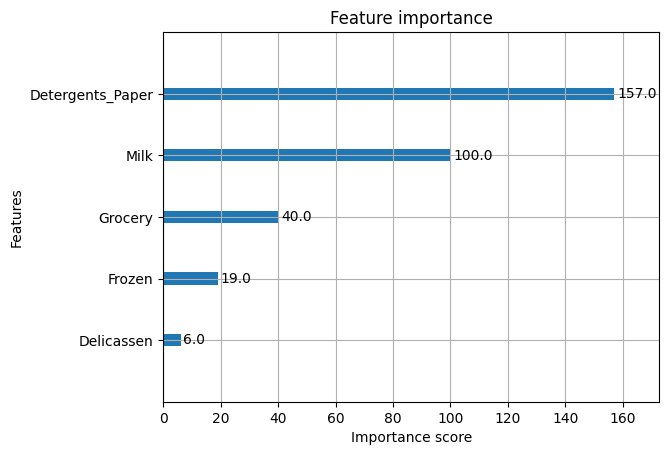

<Figure size 1600x1200 with 0 Axes>

In [58]:
xgb.plot_importance(xgb_clf)
plt.figure(figsize = (16,12))
plt.show()

In [59]:
xgb_cv.tail()

,train-auc-mean,train-auc-std,test-auc-mean,test-auc-std
30,0.974175,0.003303,0.958014,0.030325
31,0.974475,0.003352,0.958821,0.030160
32,0.974650,0.003351,0.959522,0.029064
33,0.974840,0.003303,0.959898,0.029003
34,0.974980,0.003326,0.960017,0.029139
